In [9]:
# import standard libraries 
import random
import numpy as np
import matplotlib.pyplot as plt
#import local modules
from blochstate1d import OLConstants, GroundBlochState
from errors_momentum_space import momentum_space_population, get_error
from nelder_mead_algorithm import sort_errors, nelder_mead
from crab_propagation_tools import OpticalLatticeHamiltonian, make_controls_fn

from QuEvolutio.quevolutio.core.domain import QuantumHilbertSpace, TimeGrid
from QuEvolutio.quevolutio.core.aliases import (  # isort: skip
    RVector,
    GVector,
    RVectorSeq,
    CTensors,
    CSRMatrix,
)
from QuEvolutio.quevolutio.propagators.split_operator import SplitOperator
from typing import cast
import os

In [10]:
# Define max number of iterations for the optimisation
n_max = 150
# Define the target size we want our error to be
target_error = 0.1
# Define parameters of our crab decomposition
N_basis = OLConstants().N_basis # number of basis states in our decomposition
n_c = N_basis + 1 # number of vertices in our simplex
n_w = N_basis // 2 # number of omegas, also the number of sines or cosines in our shaking function

# Generate initial amplitudes and frequencies
initial_coeffs = np.zeros(OLConstants().N_basis)
a = np.random.uniform(-10, 10, size=(n_w, n_c))
b = np.random.uniform(-10, 10, size=(n_w, n_c))
r = np.random.uniform(-0.5, 0.5, size=n_w)
omegas = np.zeros(n_w)
scaled_freq = 0.6274360876 # 25 kHz in simulation units
for i in range(n_w):
    omegas[i] = 2 * np.pi * (i + 1) * (1 + r[i]) * (scaled_freq / n_w)


In [11]:
# Run first iteration
errors = np.zeros(n_c)
for i in range(n_c):
    errors[i]  = get_error(a[:,i], b[:,i], omegas, OLConstants().N_basis)
    print(f"Initial error for vertex {i+1}: {errors[i]:.6f}")

sorted_errs, sorted_a, sorted_b = sort_errors(errors, a, b)
print("Sorted Errors:", sorted_errs)
print("Sorted a Coefficients:", sorted_a)
print("Sorted b Coefficients:", sorted_b)    

Initial error for vertex 1: 26.397399
Initial error for vertex 2: 27.111244
Initial error for vertex 3: 25.432011
Initial error for vertex 4: 65.764983
Initial error for vertex 5: 48.434395
Initial error for vertex 6: 34.716026
Initial error for vertex 7: 62.211151
Initial error for vertex 8: 11.309174
Initial error for vertex 9: 65.386035
Initial error for vertex 10: 56.769647
Initial error for vertex 11: 29.414536
Sorted Errors: [11.3091739  25.43201087 26.39739887 27.11124414 29.41453552 34.71602622
 48.43439489 56.76964681 62.21115084 65.38603515 65.76498306]
Sorted a Coefficients: [[ 4.75414752  0.01119933 -7.04600174  1.38993943  4.47870151 -6.29755249
   3.07574825 -7.30577097  7.97852411 -2.85594921  9.35704006]
 [ 0.72258903 -6.95038879  6.75486648  9.83263178  2.46840478 -8.07988688
  -1.90394136  2.58129994 -8.14603596  7.69332255 -4.98460018]
 [-8.66848671  5.30813937  6.91248685 -2.52513557 -5.14656695 -0.27171663
  -6.65083982 -1.727831    5.07895098  8.72359639  2.691449

In [12]:
# Set up arrays for tracking optimisation
best_errs = []
best_errs.append(sorted_errs[0])
all_errs = np.zeros((n_max, n_c))
all_errs[0, :] = sorted_errs

In [13]:
# Run Nelder Mead optimisation
for i in range(1, n_max):
    print(f"Iteration {i+1}")
    sorted_errs, sorted_a, sorted_b, err_NM, N_calls = nelder_mead(sorted_errs, sorted_a, sorted_b, N_basis, omegas, n_c, n_w)
    all_errs[i, :] = sorted_errs
    best_errs.append(sorted_errs[0])
    print(f"Best error after iteration {i+1}: {sorted_errs[0]:.6f}")
    print(f"Worst error after iteration {i+1}: {sorted_errs[-1]:.6f}")
    print(f"Diff between best and worst error after iteration {i+1}: {(sorted_errs[-1] - sorted_errs[0]):.6f}")
    print(f"Number of new points generated in iteration{i+1}: {N_calls}")
    # Stop the loop if the error is as small as we want it 
    if sorted_errs[0] < target_error:
        break

Iteration 2
Best error after iteration 2: 11.309174
Worst error after iteration 2: 65.386035
Diff between best and worst error after iteration 2: 54.076861
Number of new points generated in iteration2: 1
Iteration 3
Best error after iteration 3: 11.309174
Worst error after iteration 3: 62.211151
Diff between best and worst error after iteration 3: 50.901977
Number of new points generated in iteration3: 1
Iteration 4
Best error after iteration 4: 11.309174
Worst error after iteration 4: 56.769647
Diff between best and worst error after iteration 4: 45.460473
Number of new points generated in iteration4: 1
Iteration 5
Best error after iteration 5: 11.309174
Worst error after iteration 5: 54.056381
Diff between best and worst error after iteration 5: 42.747208
Number of new points generated in iteration5: 1
Iteration 6
Best error after iteration 6: 11.309174
Worst error after iteration 6: 48.434395
Diff between best and worst error after iteration 6: 37.125221
Number of new points generat

In [14]:
# Retrieve A and B coefficients and error from the final iteration
optimised_A = sorted_a[:,0]
optimised_B = sorted_b[:,0]
optimised_err = get_error(optimised_A, optimised_B, omegas, N_basis)
# Make a folder to store the best coefficients and save them
folder = "crab_coefficients"
os.makedirs(folder, exist_ok=True)
error_str = f"{optimised_err:.6f}".replace(".", "p")
np.savetxt(
    f"{folder}/best_A_error_{error_str}.txt",
    optimised_A,
    fmt="%.16f"
)

np.savetxt(
    f"{folder}/best_B_error_{error_str}.txt",
    optimised_B,
    fmt="%.16f"
)

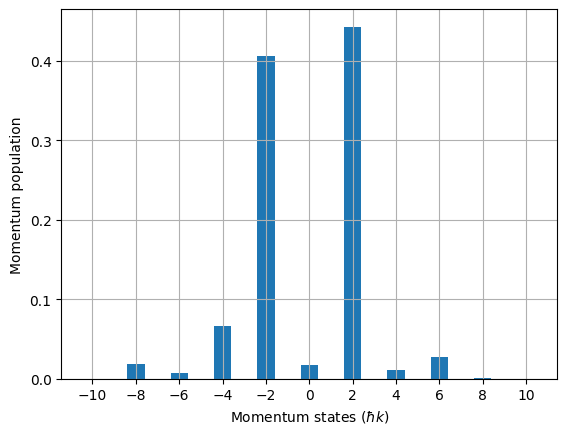

In [15]:
# Plot the final momentum state resulting from shaking with these optimised coefficients

# 1. Make the shaking function from the best coefficients from NM
controls_fn = make_controls_fn(N_basis, optimised_A, optimised_B, omegas, OLConstants().T)

# 2. Set up propagation
constants: OLConstants = OLConstants()
domain: QuantumHilbertSpace = QuantumHilbertSpace(
    num_dimensions=1,
    num_points=np.array([constants.num_pts]),
    position_bounds=np.array([[constants.lower_x_bound, constants.upper_x_bound]]),
    constants=constants,
    )
initial_state = GroundBlochState().generate_bloch_state()
state_initial: RVector = cast(
    RVector, domain.normalise_state(initial_state)
    )

hamiltonian: OpticalLatticeHamiltonian = OpticalLatticeHamiltonian(domain)

time_domain: TimeGrid = TimeGrid(time_min=0.0, time_max=constants.T, num_points=10001)

propagator = SplitOperator(hamiltonian, time_domain)

controls_fn = make_controls_fn(N_basis, optimised_A, optimised_B, omegas, constants.T)

# 3. Propagate the bloch state with the best shaking function
states: CTensors = propagator.propagate(
    state_initial, controls_fn, diagnostics=False
    )
final_state = states[-1]

# 4. Find the momentum state population of the final state

x_grid_spacing = GroundBlochState().x_grid[1] - GroundBlochState().x_grid[0]
mom_pop = momentum_space_population(final_state, x_grid_spacing)
momentum_idx = np.arange(-10, 12, 2)
# momentums = 2 * OLConstants().hbar * OLConstants().kl * momentum_idx

# 5. Plot final momentum state
plt.figure()
plt.bar(momentum_idx, mom_pop)
plt.xlabel('Momentum states ($\\hbar k$)')
plt.xticks(momentum_idx)
plt.ylabel('Momentum population')
plt.grid(True)

plt.show()